# Disag with light

## Model possibilities

Reference model: Plain LSTM (raw time-series)

Variant 1: OvO ensemble (linear MLPs) (sliding window against FFT info)

Variant 2: Hybrid CNN-LSTM (

## Imports and defs

In [33]:
import importlib
from joblib import Parallel, delayed
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scripts
import torch

DataLoader = torch.utils.data.DataLoader
ConcatDataset = torch.utils.data.ConcatDataset
optim = torch.optim
nn = torch.nn

# force reload of scripts module:
importlib.reload(scripts) # this is fine for modules without dependencies
from scripts import (
    count_num_samples,
    downsample_with_pandas,
    get_micro_dataset,
    get_sample_rate,
    get_target_devices,
    FastNILMDataset
)

torch.manual_seed(120)

Device = None
if torch.cuda.is_available():
    Device = 'cuda'
elif torch.backends.mps.is_available():
    Device = 'mps'
else:
    Device = 'cpu'

print(f'Device is {Device}')

%matplotlib inline

Device is cuda


### Model defs

In [34]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=4):
        super(BaselineLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The LSTM layer
        # batch_first=True means inputs should be (batch_size, sequence_length, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # A fully connected layer to map the LSTM hidden state to our device classes
        self.fc = nn.Linear(hidden_size, num_classes)

        # # Sigmoid for multi-label classification (outputs probabilities between 0 and 1)
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the LAST time step in the window
        out = out[:, -1, :]
        out = self.fc(out)
        # out = self.sigmoid(out)

        return out


In [35]:
desc_files = [ f for f in os.listdir("data") if f.startswith("desc_") ]
event_files_with_descs = [ os.path.splitext("events_"+f[len('desc_'):])[0] + '.csv' for f in desc_files ]
total_event_count = 0
for f in event_files_with_descs:
    f_full = os.path.join('data',f)
    if not os.path.isfile(f_full):
        print(f"File expected at {f_full} does not exist or exist yet.")
        continue
    event_count = count_num_samples(f_full)
    print(f"{f} has {event_count} events.")
    total_event_count += event_count
print(f"Total events: {total_event_count}")

events_20260501_003252_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last.csv has 2 events.
events_20260501_003902_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_004409_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_004918_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_010248_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2.csv has 2 events.
events_20260501_013851_incandescent_3-device_tango_15000_hz.csv has 20 events.
events_20260501_015332_incandescent_3-device_waltz_10000_hz.csv has 30 events.
events_20260501_021140_incandescent_4-device_mamba_10000_hz.csv has 32 events.
events_20260501_023148_incandescent_4-device_serenade_20000_hz.csv has 40 events.
events_20260501_024855_cfl_4-device_cha_cha_20000_hz.csv has 39 events.
events_20260501_

## Downsampling test:

Sample rate: 50000
Processed chunk...
Processed chunk...


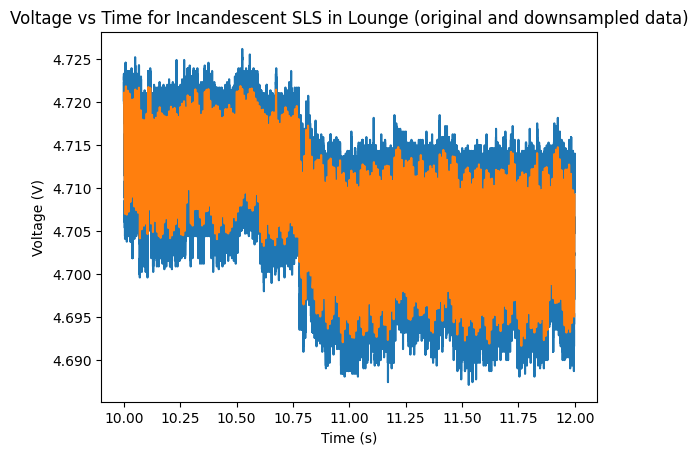

In [36]:
file_name = "data/light_20260430_211842_incandescent_sls_in_lounge_50000_hz.csv"
# file_name = "data/light_20260401_163627.csv"

sample_rate = get_sample_rate(file_name)
print(f"Sample rate: {sample_rate}")

sample1 = downsample_with_pandas(file_name, 1, skip_seconds=10, n_seconds=2)
sample2 = downsample_with_pandas(file_name, 100, skip_seconds=10, n_seconds=2)

plt.plot(sample1['elapsed_s'], sample1['voltage_V'])
plt.plot(sample2['elapsed_s'], sample2['voltage_V'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time for Incandescent SLS in Lounge (original and downsampled data)')
plt.show()


In [37]:
#STRIPME

pd.read_csv("data/events_20260501_034916_led_4-device_speedwalk_10000_hz.csv", nrows=20)

,sample_index,elapsed_s,label
0,141000,14.1,space_heater_on
1,246000,24.6,space_heater_off
2,300000,30.0,fridge_on
3,605000,60.5,fridge_off
4,859000,85.9,kettle_on
5,904000,90.4,kettle_off
6,928000,92.8,sls_on
7,2132000,213.2,sls_off


## Data preprocessing setup

In [38]:
def generate_state_matrix(voltage_df, events_df, target_devices):
    """Calculates the continuous 1s, 0s, and -1s (uncertainty) state matrix."""
    state_matrix = np.zeros((len(voltage_df), len(target_devices)), dtype=np.float32)
    current_state = {dev: 0.0 for dev in target_devices}
    uncertain_until = {dev: 0.0 for dev in target_devices}
    UNCERTAINTY_WINDOW = 30.0

    event_idx = 0
    num_events = len(events_df)

    for i, elapsed_s in enumerate(voltage_df['elapsed_s'].values):
        while event_idx < num_events and elapsed_s >= events_df.iloc[event_idx]['elapsed_s']:
            event_str = events_df.iloc[event_idx]['label']
            event_time = events_df.iloc[event_idx]['elapsed_s']

            for dev in target_devices:
                if dev in event_str:
                    if "_on" in event_str:
                        current_state[dev] = -1.0
                        uncertain_until[dev] = event_time + UNCERTAINTY_WINDOW
                    elif "_off" in event_str:
                        current_state[dev] = 0.0
                        uncertain_until[dev] = 0.0
            event_idx += 1

        for dev in target_devices:
            if current_state[dev] == -1.0 and elapsed_s >= uncertain_until[dev]:
                current_state[dev] = 1.0

        for dev_idx, dev in enumerate(target_devices):
            state_matrix[i, dev_idx] = current_state[dev]

    return state_matrix


def _process_single_file(desc_f, data_dir, output_dir, target_hz, force_rebuild, global_devices):
    base_suffix = os.path.splitext(desc_f[len('desc_'):])[0]
    out_path = os.path.join(output_dir, f"{base_suffix}.npz")

    # --- THE NO-OP CHECK ---
    if os.path.exists(out_path) and not force_rebuild:
        return f"[~] Skipping {base_suffix}: Already preprocessed."

    event_full = os.path.join(data_dir, f"events_{base_suffix}.csv")
    light_full = os.path.join(data_dir, f"light_{base_suffix}.csv")

    if not (os.path.isfile(event_full) and os.path.isfile(light_full)):
        return f"[-] Skipping {base_suffix}: Missing CSVs."
    if count_num_samples(event_full, harsh=False) == 0:
        return f"[-] Skipping {base_suffix}: 0 events."

    # Downsample
    native_hz = get_sample_rate(light_full)
    dynamic_factor = max(1, native_hz // target_hz)
    voltage_df = downsample_with_pandas(input_file=light_full, factor=dynamic_factor)
    events_df = pd.read_csv(event_full)

    # Calculate matrix
    state_matrix = generate_state_matrix(voltage_df, events_df, global_devices)

    # Save as highly compressed binary NumPy format
    np.savez_compressed(
        out_path,
        voltage=voltage_df['voltage_V'].values,
        states=state_matrix,
        devices=global_devices
    )
    return f"[+] Processed and saved: {base_suffix}.npz"


def compile_datasets(data_dir="data", output_dir="preprocess_cache", target_hz=100, force_rebuild=False):
    os.makedirs(output_dir, exist_ok=True)

    # 1. Global Devices
    desc_files = [f for f in os.listdir(data_dir) if f.startswith("desc_") and f.endswith(".json")]
    global_devices = set()
    for f in desc_files:
        devices = get_target_devices(os.path.join(data_dir, f))
        global_devices.update(devices)
    global_devices = sorted(list(global_devices))

    print(f"Global Targets: {global_devices}")
    print(f"Starting parallel processing of {len(desc_files)} files using Joblib...")

    # 2. Execute parallel pool!
    # n_jobs=-1 tells it to use all available CPU cores.
    results = Parallel(n_jobs=-1)(
        delayed(_process_single_file)(
            desc_f, data_dir, output_dir, target_hz, force_rebuild, global_devices
        ) for desc_f in desc_files
    )

    # 3. Print the return strings cleanly
    for result_string in results:
        print(result_string)

    print("\n[*] All files preprocessed successfully!")




## Data preprocessing

In [39]:
downsample_target_hz = 100
compile_datasets(force_rebuild=False, target_hz=downsample_target_hz)

Global Targets: ['dell', 'fridge', 'kettle', 'lamp', 'sls', 'space_heater']
Starting parallel processing of 41 files using Joblib...
[~] Skipping 20260501_003252_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last: Already preprocessed.
[~] Skipping 20260501_003902_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2: Already preprocessed.
[~] Skipping 20260501_004409_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2: Already preprocessed.
[~] Skipping 20260501_004918_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2: Already preprocessed.
[~] Skipping 20260501_010248_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last_2: Already preprocessed.
[~] Skipping 20260501_013851_incandescent_3-device_tango_15000_hz: Already preprocessed.
[~] Skipping 20260501_015332_incandescent_3-device_waltz_10000_hz: Already preprocessed.
[~] Skipping 20260501_021140_incandescent

## Data loading setup

In [40]:
def load_fast_datasets(preprocess_dir="preprocess_cache", window_size=200,specific_files=None):
    """ specific_files  --  process a specific list of files instead of a directory """
    all_datasets = []

    npz_files = specific_files if specific_files else [
        f for f in os.listdir(preprocess_dir) if f.endswith(".npz")
    ]

    for f in npz_files:
        full_path = os.path.join(preprocess_dir, f)
        dataset = FastNILMDataset(full_path, window_size=window_size)
        all_datasets.append(dataset)

    master_dataset = ConcatDataset(all_datasets)

    # Optional: Load the devices array from the first file just so we know what they are
    sample_data = np.load(os.path.join(preprocess_dir, npz_files[0]))
    classes = sample_data['devices']

    print(f"Loaded {len(all_datasets)} datasets!")
    print(f"Total windowed samples for training: {len(master_dataset)}")

    return master_dataset, classes



## Data loading

Processed chunk...
Loading round-trip data from preprocess_cache\20260501_031802_led_4-device_chicken_dance_10000_hz.npz...


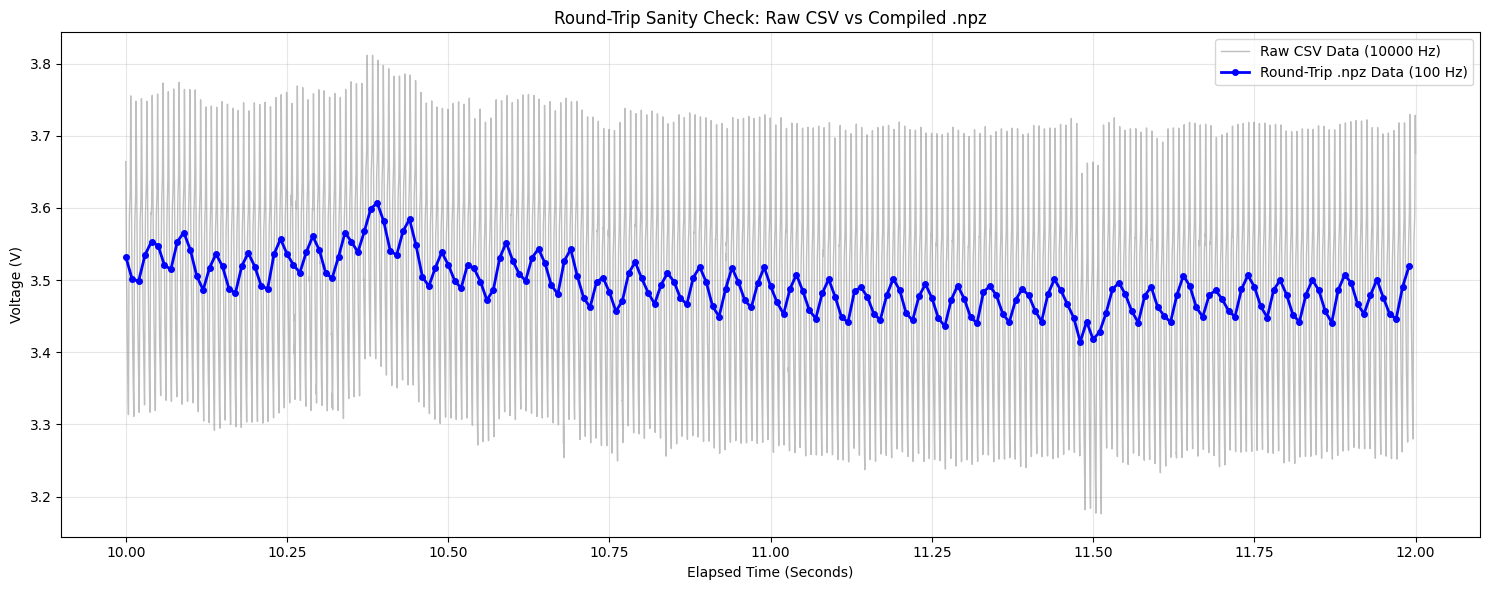

In [41]:
import re

def plot_sanity_check(raw_csv=None, npz_file=None, target_hz=100, offset_seconds=10, duration_seconds=2.0, npz_dir="preprocess_cache", csv_dir="data"):

    def we_can_rebuild_him(basis_file,new_dir,new_ext,strippattern='',addpattern=''):
        return os.path.join(
            new_dir,
            os.path.splitext(addpattern+re.sub(strippattern,'',os.path.basename(basis_file)))[0] + new_ext
        )

    if not raw_csv and not npz_file:
        raise ValueError("raw_csv or npz_file must be provided.")
    elif raw_csv:
        npz_file = we_can_rebuild_him(raw_csv, npz_dir, '.npz', strippattern='^light_')
    else:
        raw_csv = we_can_rebuild_him(npz_file, csv_dir, '.csv', addpattern='light_')

    # 1. Figure out native sample rate and load a chunk of RAW data
    native_hz = get_sample_rate(raw_csv)
    raw_df = downsample_with_pandas(raw_csv, 1, n_seconds=duration_seconds, skip_seconds=offset_seconds)

    # 2. Load the fully processed .npz Cache file
    print(f"Loading round-trip data from {npz_file}...")
    data = np.load(npz_file)
    npz_voltage = data['voltage']

    # Slice exactly the right number of downsampled items from the .npz array
    npz_samples_to_read = int(target_hz * duration_seconds)
    npz_sample_offset = int(offset_seconds * target_hz)
    npz_voltage_slice = npz_voltage[npz_sample_offset:npz_sample_offset+npz_samples_to_read]

    # 3. Reconstruct the time-axis for the .npz file so they overlay
    # We grab the starting time of the raw data and step by 1/target_hz
    t0 = raw_df['elapsed_s'].iloc[0]
    npz_time = t0 + (np.arange(len(npz_voltage_slice)) * (1.0 / target_hz))

    # 4. Plot them on top of each other
    plt.figure(figsize=(15, 6))

    # Plot raw data (Semi-transparent gray)
    plt.plot(raw_df['elapsed_s'], raw_df['voltage_V'],
             label=f'Raw CSV Data ({native_hz} Hz)',
             alpha=0.5, color='gray', linewidth=1)

    # Plot the round-trip .npz data (Thick blue line with dots)
    plt.plot(npz_time, npz_voltage_slice,
             label=f'Round-Trip .npz Data ({target_hz} Hz)',
             linewidth=2, color='blue', marker='o', markersize=4)

    plt.title(f"Round-Trip Sanity Check: Raw CSV vs Compiled .npz")
    plt.xlabel("Elapsed Time (Seconds)")
    plt.ylabel("Voltage (V)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_sanity_check(raw_csv="data\\light_20260501_031802_led_4-device_chicken_dance_10000_hz.csv", target_hz=downsample_target_hz)

In [42]:
# dataset, classes = load_fast_datasets(window_size=200)

micro_files = get_micro_dataset()
dataset, classes = load_fast_datasets(window_size=200, specific_files=micro_files)

train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

[*] Scanning cache for device coverage...
[*] Found 2 unique devices across 40 files.

[*] Assembling minimum file set:
 [+] Added 20260501_003252_incandescent_sls_in_lounge_autocollect_bombproofing_15000_hz_hopefully_last.npz -> Covered: [np.str_('sls')]
 [+] Added 20260501_213142_led_archies_computer_in_the_lounge_medium_dist_3.npz -> Covered: [np.str_('kettle')]

[SUCCESS] Reduced 40 files down to 2 files!
Loaded 2 datasets!
Total windowed samples for training: 83326


## Training setup

In [ ]:
def train_model(train_loader, num_classes, num_epochs=5, learning_rate=0.001):
    # 1. Setup Device (CUDA for NVIDIA, MPS for Apple Silicon, CPU as fallback)
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"[*] Training on device: {device}")

    # 2. Instantiate the Model
    # Make sure we pass the dynamic number of classes we found in the data!
    model = BaselineLSTM(input_size=1, hidden_size=64, num_layers=2, num_classes=num_classes)
    model.to(device)

    # 3. Define Loss and Optimizer
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print("\n[*] Beginning Training Loop...")

    # 4. The Epoch Loop
    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            # Move data to the correct device
            inputs, targets = inputs.to(device), targets.to(device)

            # Step A: Zero the gradients
            optimizer.zero_grad()

            # Step B: Forward Pass (Predict)
            outputs = model(inputs)

            # Step C: Calculate Loss
            loss = criterion(outputs, targets)

            # Step D: Backward Pass (Calculate gradients)
            loss.backward()

            # Step E: Update Weights
            optimizer.step()

            running_loss += loss.item()

            # Print a progress update every 100 batches
            if (batch_idx + 1) % 100 == 0:
                avg_loss = running_loss / 100
                print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {avg_loss:.4f}")
                running_loss = 0.0

    print("[+] Training Complete!")
    return model

## Training

In [45]:
print(f"[*] Tracking {len(classes)} devices: {classes}")

# Fire up the training loop!
trained_model = train_model(train_loader, num_classes=len(classes), num_epochs=3)

[*] Tracking 6 devices: ['dell' 'fridge' 'kettle' 'lamp' 'sls' 'space_heater']
[*] Training on device: cuda

[*] Beginning Training Loop...
Epoch [1/3] | Batch [100/5208] | Loss: 0.2280
Epoch [1/3] | Batch [200/5208] | Loss: 0.1114
Epoch [1/3] | Batch [300/5208] | Loss: 0.1179
Epoch [1/3] | Batch [400/5208] | Loss: 0.1104
Epoch [1/3] | Batch [500/5208] | Loss: 0.1121
Epoch [1/3] | Batch [600/5208] | Loss: 0.1120
Epoch [1/3] | Batch [700/5208] | Loss: 0.1072
Epoch [1/3] | Batch [800/5208] | Loss: 0.0999
Epoch [1/3] | Batch [900/5208] | Loss: 0.0970
Epoch [1/3] | Batch [1000/5208] | Loss: 0.0822
Epoch [1/3] | Batch [1100/5208] | Loss: 0.0682
Epoch [1/3] | Batch [1200/5208] | Loss: 0.0697
Epoch [1/3] | Batch [1300/5208] | Loss: 0.0656
Epoch [1/3] | Batch [1400/5208] | Loss: 0.0783
Epoch [1/3] | Batch [1500/5208] | Loss: 0.0900
Epoch [1/3] | Batch [1600/5208] | Loss: 0.0942
Epoch [1/3] | Batch [1700/5208] | Loss: 0.0874
Epoch [1/3] | Batch [1800/5208] | Loss: 0.0926
Epoch [1/3] | Batch [19